##### ***BERT(Bidirectional Encoder Representations from Transformers)***
###### 回看之前的模型，无论是word2vec还是GloVe，都会给同一个词分配一个固定的词向量，但这样的缺点也显而易见：对于多义词来说，模型并没有考虑上下文信息，因此对句子语义的表达能力有限。于是便出现了上下文敏感的词表示模型，例如TagLM、CoVe和ELMo。不过这些模型大多仍然依赖RNN来提取上下文，难以并行计算，也不容易捕获更长距离的依赖关系。并且ELMo只能处理特定任务架构，意味着对于不同的任务需要自己设计一个任务特定的模型，相当的耗时麻烦。而与之对应的GPT(Generative Pre Traning)模型则由于其自回归的特性的是任务无关类的模型，但是缺点也很明显就是无法看到上下文，只能从左往右。随着Transformer的提出，人们开始尝试直接基于自注意力机制来做预训练语言模型，BERT便是结合了ELMo和GPT的优点诞生的。而ELMo、GPT和BERT的差异如下图：
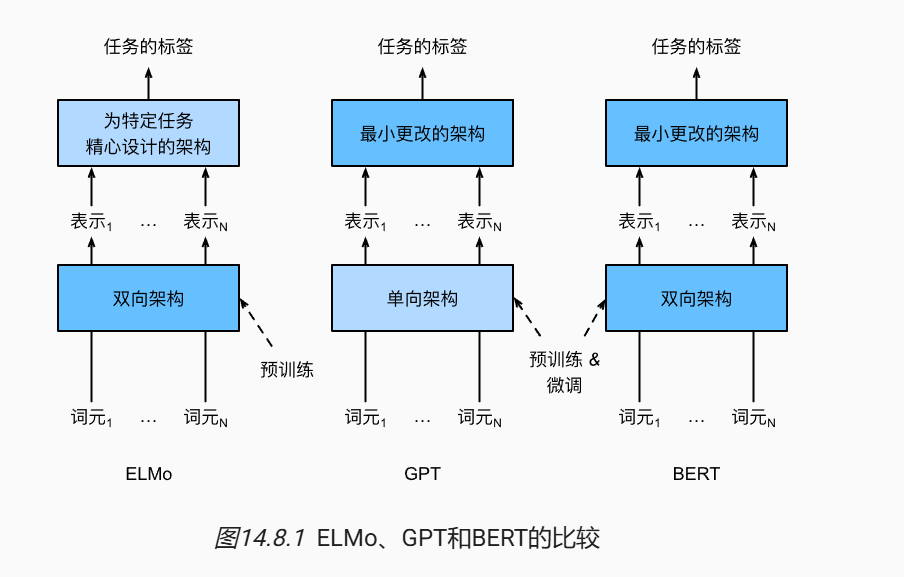
##### ***BERT的核心思想***
###### BERT的全称是Bidirectional Encoder Representations from Transformers，也就是来自Transformer的双向编码表示。这里最关键的词有两个：**Bidirectional**和**Encoder**。所谓双向，指的是模型在表示一个词元时，可以同时利用左侧和右侧的上下文信息；所谓编码器，则意味着BERT继承的是Transformer中的编码器部分，而不是完整的编码器-解码器结构。因此BERT本质上是一个**encoder-only**模型，更偏向于语言理解，而不是一步一步地生成文本。
###### 例如在句子“我去银行取钱”和“河边有一座银行大楼”中，“银行”一词的含义显然不同。静态词向量会给这两个“银行”分配相同的表示，而BERT会根据上下文动态生成不同的表示，因此更适合理解任务。
##### ***BERT的模型结构***
###### 从架构上看，BERT直接使用了Transformer编码器的堆叠结构。也就是说，每一层都由多头自注意力机制、前馈网络、残差连接以及层归一化组成。输入序列首先经过嵌入层，再送入多层Transformer Encoder中，最后得到每个词元对应的上下文表示。由于没有解码器部分，所以BERT不像Seq2Seq模型那样用于逐词生成，而是更关注“输入序列中每个位置学到了什么语义表示”。
##### ***BERT的输入格式***
###### BERT通常会在输入前加上特殊词元`[CLS]`，在句子结束处加上`[SEP]`。其中`[CLS]`对应的最终隐藏状态常常被拿来作为整句的表示，用于分类任务；`[SEP]`则用于分隔两个句子。例如对于句子对输入：
###### `[CLS] 我喜欢深度学习 [SEP] 它很有意思 [SEP]`
###### 模型不仅能学习每个词的上下文表示，还能够利用`[CLS]`位置聚合整段输入的全局语义。
###### 具体来说，首先BERT将输入默认为单句或者双句，前者在tokens开头加上`[CLS]`，tokens结尾添加`[SEP]`标记句子结束。对于后者，句子对中的单句按照单句的操作将两个句子进行连接，不过为区分句子对位置关系，会对第一个句子额外添加一个e_A向量，对第二个添加e_B。这两个向量都可以学习。
###### BERT的输入表示由三部分相加得到：
$$Input = Token\ Embedding + Segment\ Embedding + Position\ Embedding$$
###### 其中，Token Embedding表示词元本身，Segment Embedding用于区分句子对任务中的前一句和后一句，Position Embedding则用于保留位置信息。与Transformer原论文中的固定正弦位置编码不同，BERT使用的是**可学习的位置嵌入**。
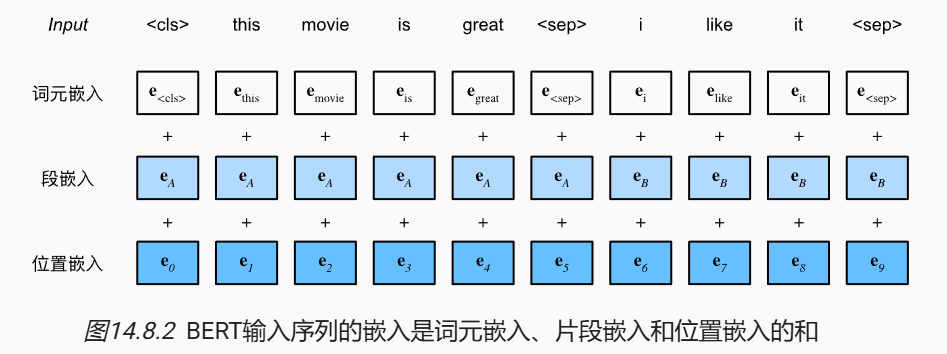


In [ ]:
import torch
from torch import nn 
from d2l import torch as d2l

#@save
def get_tokens_and_segments(tokens_a, tokens_b=None):
    """获取输入序列的词元及其片段索引"""
    tokens = ['<cls>'] + tokens_a + ['<seq>']
    segments = [0] * (len(tokens_a) + 2)
    if tokens_b is not None:
        tokens += tokens + ['<sep>']
        segments = [1] * (len(tokens_b) + 1)
    return tokens, segments

In [26]:
# 基于TransformerEncoder实现BERTEncoder
class BERTEncoder(nn.Module):
    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, num_layers, dropout, max_len = 1000, key_size = 768, query_size = 768, value_size = 768, **kwargs):
        super(BERTEncoder, self).__init__(**kwargs)
        self.token_embedding = nn.Embedding(vocab_size, num_hiddens)
        self.segment_embedding = nn.Embedding(2, num_hiddens)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module(f"{i}", d2l.EncoderBlock(
                key_size, query_size, value_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, dropout, True
                )
            )
        # 在BERT中，位置嵌入是可以学习的，因此我们需要创建一个足够长的位置嵌入参数
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, num_hiddens))
    
    def forward(self, tokens, segments, valid_lens):
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding.data[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X 

In [27]:
vocab_size, num_hiddens, ffn_num_hiddens, num_heads = 10000, 768, 1024, 4
norm_shape, ffn_num_input, num_layers, dropout = [768], 768, 2, 0.2
encoder = BERTEncoder(vocab_size, num_hiddens, norm_shape, ffn_num_input,
                      ffn_num_hiddens, num_heads, num_layers, dropout)

In [28]:
tokens = torch.randint(0, vocab_size, (2, 8))
segments = torch.tensor([[0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 1, 1, 1, 1, 1]])
encoded_X = encoder(tokens, segments, None)
encoded_X.shape

torch.Size([2, 8, 768])

##### ***BERT的预训练任务***
###### BERT最经典的地方就在于它的预训练方式。由于模型希望同时利用双向上下文，因此不能像GPT那样直接做从左到右的next-token prediction，否则未来信息就会泄露。为了解决这个问题，BERT提出了两种预训练任务：**掩码语言模型**和**下一句预测**。
##### ***掩码语言模型MLM(Masked Language Model)***
###### 在掩码语言模型任务中，训练时会随机选取输入中15%的词元进行预测。而对于这选中的15%词元来说，常见做法是：80%的情况下用`[MASK]`替换，10%的情况下替换成其他随机词元，剩下10%保持原词不变。模型的目标是根据未被遮蔽的上下文去恢复这些被选中的词。假设第$i$个位置被掩蔽，那么模型需要最大化：
$$P(x_i \mid x_1,\cdots, x_{i-1}, x_{i+1},\cdots, x_n)$$
###### 这说明BERT在预测一个词时，可以同时利用左右两侧的信息，因此得到的是双向上下文表示。也正因为这种训练方式，BERT特别适合理解任务，但不天然适合自回归生成任务。


In [29]:
#@save
class MaskLM(nn.Module):
    """BERT的掩蔽语言模型任务"""
    def __init__(self, vocab_size, num_hiddens, num_inputs=768, **kwargs):
        super(MaskLM, self).__init__(**kwargs)
        self.mlp = nn.Sequential(nn.Linear(num_inputs, num_hiddens),
                                 nn.ReLU(),
                                 nn.LayerNorm(num_hiddens),
                                 nn.Linear(num_hiddens, vocab_size))

    def forward(self, X, pred_positions):
        # pred_positions.shape = (batch_size, num_pred_positions)
        num_pred_positions = pred_positions.shape[1]
        pred_positions = pred_positions.reshape(-1) # 展平
        batch_size = X.shape[0]
        batch_idx = torch.arange(0, batch_size)
        # 假设batch_size=2，num_pred_positions=3
        # 那么batch_idx是np.array（[0,0,0,1,1,1]）
        batch_idx = torch.repeat_interleave(batch_idx, num_pred_positions)
        masked_X = X[batch_idx, pred_positions]
        masked_X = masked_X.reshape((batch_size, num_pred_positions, -1))
        mlm_Y_hat = self.mlp(masked_X)
        return mlm_Y_hat

In [30]:
mlm = MaskLM(vocab_size, num_hiddens)
mlm_positions = torch.tensor([[1, 5, 2], [6, 1, 5]])
mlm_Y_hat = mlm(encoded_X, mlm_positions)
mlm_Y_hat.shape

torch.Size([2, 3, 10000])

In [31]:
mlm_Y = torch.tensor([[7, 8, 9], [10, 20, 30]])
loss = nn.CrossEntropyLoss(reduction='none')
mlm_l = loss(mlm_Y_hat.reshape((-1, vocab_size)), mlm_Y.reshape(-1))
mlm_l.shape

torch.Size([6])

##### ***下一句预测NSP(Next Sentence Prediction)***
###### 尽管MLM可以通过上下文来表示单词帮助理解，但是它不能显式的建模文本对之间的逻辑关系，也就是说对于一个句子对，它无法判断第二个句子是不是第一个句子的后续，所以原始BERT还设计了下一句预测任务。具体来说，输入两个句子，有50%的概率，第二个句子的第一个句子的后续，但是另外的50%概率则是从其他语料中抽取的不相干句子。模型利用`[CLS]`位置的表示来判断这两个句子是否连续。这个任务的目的是让模型学习句间关系，从而更好地适应问答、自然语言推断等需要句子对建模的任务。
###### 不过后续研究表明，NSP并不是BERT性能提升的最关键因素，因此像RoBERTa这样的改进模型便移除了NSP任务，并通过更大规模的数据和更充分的训练取得了更好的效果。


In [32]:
class NextSentencePred(nn.Module):
    def __init__(self, num_inputs, **kwargs):
        super(NextSentencePred, self).__init__(**kwargs)
        self.output = nn.Linear(num_inputs, 2)
    
    def forward(self, X):
        # X.shape = (batch_size, num_hiddens)
        return self.output(X)

In [33]:
encoded_X = torch.flatten(encoded_X, start_dim=1)
nsp = NextSentencePred(encoded_X.shape[-1])
nsp_Y_hat = nsp(encoded_X)
nsp_Y_hat.shape

torch.Size([2, 2])

In [34]:
nsp_y = torch.tensor([0, 1])
nsp_l = loss(nsp_Y_hat, nsp_y)
nsp_l

tensor([0.7083, 1.0446], grad_fn=<NllLossBackward0>)

In [35]:
# 代码整合
class BERTModel(nn.Module):
    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, num_layers, dropout, max_len=1000, key_size=768, query_size=768, value_size=768, hid_in_features=768, mlm_in_features=768, nsp_in_features=768):
        super(BERTModel, self).__init__()
        self.encoder = BERTEncoder(vocab_size, num_hiddens, norm_shape, num_layers, ffn_num_input, ffn_num_hiddens, num_heads, num_layers, dropout, max_len=max_len, key_size=key_size, query_size=query_size, value_size=value_size)
        self.hidden = nn.Sequential(nn.Linear(hid_in_features, num_hiddens), nn.Tanh())
        self.mlm = MaskLM(vocab_size, num_hiddens, mlm_in_features)
        self.nsp = NextSentencePred(nsp_in_features)
    
    def forward(self, tokens, segments, valid_lens=None, pred_positions=None):
        encoded_X = self.encoder(tokens, segments, valid_lens)
        if pred_positions is not None:
            mlm_Y_hat = self.mlm(encoded_X, pred_positions)
        else:
            mlm_Y_hat = None
        nsp_Y_hat = self.nsp(self.hidden(encoded_X[:, 0, :]))
        return encoded_X, mlm_Y_hat, nsp_Y_hat

##### ***BERT为什么适合理解任务***
###### 因为BERT在每一层都使用双向自注意力，所以每个词元都能看到整个输入序列，从而形成强上下文化表示。对于文本分类、情感分析、命名实体识别、问答和句子匹配这类任务来说，模型的重点不是“生成下一个词”，而是“理解输入到底表达了什么”。这正是BERT最擅长的地方。
###### 例如在文本分类中，我们可以直接取`[CLS]`位置的表示，接一个线性层输出类别；在序列标注任务中，则可以取每个词元对应的隐藏状态，对每个位置分别做分类。
##### ***BERT的微调方式***
###### 在完成预训练后，BERT可以通过微调来适配不同下游任务。微调的思想很直接：保留预训练得到的参数初始化，然后在具体任务数据集上继续训练少量任务相关参数，甚至直接整体联合训练。相比从零开始训练，预训练后的BERT已经掌握了大量语言知识，因此只需要较少样本，就能在具体任务上取得不错的效果。
###### 这也意味着BERT的训练流程可以概括为：
###### **预训练Pre-training -> 下游任务微调Fine-tuning**
###### 其中预训练负责学到通用语言表示，微调负责将这些表示迁移到具体任务上。
##### ***BERT与Transformer、GPT、Seq2Seq的关系***
###### 从结构来源上看，BERT继承自Transformer，但只保留了编码器部分，因此它不是完整的Transformer翻译模型。Transformer最初是为Seq2Seq任务提出的，属于编码器-解码器架构；BERT则将其中的编码器单独拿出来，发展成专门做理解的预训练模型。
###### 与BERT不同，GPT使用的是Transformer的解码器路线，并采用自回归方式进行训练，也就是根据前文预测下一个词。因此二者最大的差异在于：
###### 1. BERT是**双向建模**，更适合理解；
###### 2. GPT是**单向自回归建模**，更适合生成；
###### 3. Seq2Seq模型更适合翻译、摘要这类输入输出都明确的任务。
###### 所以可以简单记成：**BERT偏理解，GPT偏生成，经典Transformer最早偏Seq2Seq。**
##### ***BERT的优点与局限性***
###### BERT的优点在于：一方面它利用双向上下文表示，大幅提升了语言理解能力；另一方面它把预训练和微调结合起来，使得NLP任务不再需要从零开始设计复杂模型，而是可以基于统一的预训练模型进行迁移。
###### 但BERT也有很明显的局限性。首先，它的MLM训练方式与推理阶段并不完全一致，因为预训练中使用了`[MASK]`，而实际应用时通常并不会出现这个特殊词元；其次，BERT不是自回归模型，不擅长长文本连续生成；最后，随着模型规模和应用场景扩大，encoder-only结构在通用生成式任务上逐渐被GPT类decoder-only模型超越。
##### ***从BERT到现代LLM的视角***
###### 从今天的角度回看，BERT最大的意义并不只是它在具体榜单上取得了多高的成绩，而是它证明了：**大规模预训练 + 下游微调**这条路线是可行的。后续的GPT、T5、BART以及更大规模的LLM，都继承了“先进行大规模预训练，再针对目标行为进行后续适配”的核心思想。只不过BERT更偏理解，现代主流LLM则更多走向了生成式路线。
###### 因此在学习路径上，可以把BERT看作是从词向量时代走向大模型时代的重要桥梁：它承接了上下文表示学习的需求，又借助Transformer打开了预训练语言模型的新阶段。
##### ***总结***
###### BERT是一个基于Transformer编码器的双向预训练语言模型，它通过MLM和NSP等任务学习上下文敏感的表示，特别适合理解类NLP任务。它既不同于最初用于翻译的Seq2Seq Transformer，也不同于后来的GPT式生成模型，但它在“预训练+微调”范式上的成功，为现代LLM的发展奠定了非常重要的基础。